# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## TRANSFORMER REGRESSION

This notebook trains a transformer model to predict solution cost (regression) from binary facility-selection vectors generated by the p-median workflow.

### SETTING THE ENVIRONMENT

Importing the libraries:

In [1]:
import copy
import torch
import random
import warnings

import numpy   as np
import pandas  as pd
import seaborn as sns
import matplotlib.pyplot as plt

from torch            import nn
from torch.utils.data import DataLoader, \
                             TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_absolute_error, \
                                    mean_squared_error , \
                                    r2_score

from lib import ensure_project_on_path, \
                instances_dir         , \
                long_term_memory_to_arrays

In [2]:
warnings.filterwarnings("ignore")

sns.set_theme(
    style="whitegrid", context="notebook"
)

plt.rcParams["figure.dpi"] = 110

In [3]:
SEED = 42


random      .seed(SEED)
np.random   .seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print(f"Device: {DEVICE}.")

Device: cuda.


### LOAD SOLUTIONS

Load solutions from pymedian:

In [4]:
def load_solutions_from_pymedian(
    instance_name="pmed11.txt",
    restarts     =8 ,
    max_iter     =25,
    factor       =2 ,
):
    project_root = ensure_project_on_path()

    import pymedian

    instance_path = instances_dir(project_root) / instance_name

    if not instance_path.exists():
        raise FileNotFoundError(
            f"Instance not found: {instance_path}"
        )

    summary, details = pymedian.solve_pmedian(
        str(instance_path),
        restarts      =restarts ,
        max_iter      =max_iter ,
        factor        =factor   ,
        details_format="indices",
    )

    memory = details.get("long_term_memory", [])
    solution_arrays = long_term_memory_to_arrays(
        memory,
        summary["n"],
        details_format="indices",
    )

    return summary, details, solution_arrays.X, solution_arrays.costs

In [5]:
INSTANCE_NAME = "pmed11.txt"

RESTARTS = 8
MAX_ITER = 25
FACTOR   = 2


summary, details, X, y = load_solutions_from_pymedian(
    instance_name=INSTANCE_NAME,
    restarts     =RESTARTS,
    max_iter     =MAX_ITER,
    factor       =FACTOR  ,
)


print(f"Instance {summary['instance']}!")
print()

print(f"There are {len(X)} solutions in long-term memory."   )
print(f"Cost range between [{int(y.min())}, {int(y.max())}].")

Instance /home/rei-luisinho/xopt/instances/pmed11.txt!

There are 778 solutions in long-term memory.
Cost range between [7696, 7846].


In [6]:
BATCH_SIZE = 64


X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size   =0.20,
    random_state=SEED,
    shuffle     =True,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size   =0.25,
    random_state=SEED,
    shuffle     =True,
)


y_mean = float(y_train.mean())
y_std  = float(y_train.std ())

if np.isclose(y_std, 0.0):
    y_std = 1.0

y_train_z = (y_train - y_mean) / y_std
y_val_z   = (y_val   - y_mean) / y_std
y_test_z  = (y_test  - y_mean) / y_std

X_train_t = torch.tensor(X_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val  , dtype=torch.long)
X_test_t  = torch.tensor(X_test , dtype=torch.long)

y_train_t = torch.tensor(y_train_z, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_z  , dtype=torch.float32)
y_test_t  = torch.tensor(y_test_z , dtype=torch.float32)


train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True )
val_loader   = DataLoader(TensorDataset(X_val_t  , y_val_t  ), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t , y_test_t ), batch_size=BATCH_SIZE, shuffle=False)


print(f"Batch size is {BATCH_SIZE}!")
print()

print(f"Train size = {len(X_train_t)}")
print(f"Val   size = {len(X_val_t  )}")
print(f"Test  size = {len(X_test_t )}")

Batch size is 64!

Train size = 466
Val   size = 156
Test  size = 156


### TRANSFORMERS ARCHITECTURE

In [7]:
class AttentionBlock(nn.Module):
    def __init__(
        self,
        d_model: int,
        n_heads: int,
        dropout: float = 0.1
    ):
        super().__init__()

        self.mha = nn.MultiheadAttention(
            embed_dim  =d_model,
            num_heads  =n_heads,
            dropout    =dropout,
            batch_first=True,
        )

        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout  (dropout)

        self.ffn = nn.Sequential(
            nn.Linear (d_model, 4 * d_model),
            nn.GELU   (       ),
            nn.Dropout(dropout),
            nn.Linear (4 * d_model, d_model),
        )

    def forward(
        self,
        x          : torch.Tensor,
        return_attn: bool = False,
    ):
        attn_out, attn = self.mha(
            x,
            x,
            x,
            need_weights  =return_attn,
            average_attn_weights=False,
        )

        x = self.norm1(x + self.dropout(attn_out))

        ff_out = self.ffn(x)

        x = self.norm2(x + self.dropout(ff_out))

        return x, attn


class FacilityTransformerRegressor(nn.Module):
    def __init__(
        self,
        n_facilities: int,
        d_model     : int   = 400 ,
        n_heads     : int   = 5   ,
        n_layers    : int   = 1   ,
        dropout     : float = 0.15,
    ):
        super().__init__()

        if d_model % n_heads != 0:
            raise ValueError(
                f"d_model={d_model} must be divisible by n_heads={n_heads}."
            )

        self.n_facilities = n_facilities

        self.state_embed    = nn.Embedding(2           , d_model)
        self.facility_embed = nn.Embedding(n_facilities, d_model)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        self.blocks = nn.ModuleList(
            [
                AttentionBlock(
                    d_model=d_model, n_heads=n_heads, dropout=dropout
                )
                for _ in range(n_layers)
            ]
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model         ),
            nn.Linear   (d_model, d_model),
            nn.GELU     (),
            nn.Dropout  (dropout   ),
            nn.Linear   (d_model, 1),
        )

        self.register_buffer(
            "facility_ids",
            torch.arange(
                n_facilities, dtype=torch.long
            ),
            persistent=False
        )

        nn.init.normal_(self.cls_token, mean=0.0, std=0.02)

    def forward(self, x_bin: torch.Tensor, return_attn: bool = False):
        x_bin = x_bin.clamp_(0, 1)

        batch_size, n = x_bin.shape
        if n != self.n_facilities:
            raise ValueError(f"Expected {self.n_facilities} facilities, got {n}.")

        ids = self.facility_ids.unsqueeze(0).expand(batch_size, n)

        token_states     = self.state_embed   (x_bin)
        token_facilities = self.facility_embed(ids  )

        tokens = token_states + token_facilities

        cls = self.cls_token.expand(batch_size, -1, -1)
        h   = torch.cat([cls, tokens], dim=1)

        attn_maps = []
        for block in self.blocks:
            h, attn = block(h, return_attn=return_attn)

            if return_attn:
                attn_maps.append(attn)

        pred = self.head(h[:, 0, :]).squeeze(-1)

        if return_attn:
            return pred, attn_maps

        return pred

In [8]:
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None

    model.train(training)

    total_loss  = 0.0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        if training:
            optimizer.zero_grad()

        pred = model(xb)

        loss = nn.functional.mse_loss(
            pred, yb
        )

        if training:
            loss .backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )

            optimizer.step()

        batch_n = xb.size(0)

        total_loss  += float(loss.item()) * batch_n
        total_count += batch_n

    return total_loss / max(1, total_count)


@torch.no_grad()
def predict_costs(model, X_np: np.ndarray):
    model.eval()

    X_t    = torch.tensor(X_np, dtype=torch.long)
    loader = DataLoader  (
        TensorDataset(X_t), batch_size=128, shuffle=False
    )

    preds_z = []
    for (xb,) in loader:
        xb = xb.to(DEVICE)

        preds_z.append(
            model(xb).cpu().numpy()
        )

    preds_z = np.concatenate(preds_z, axis=0)

    return preds_z * y_std + y_mean


@torch.no_grad()
def evaluate_metrics(
    model,
    X_np: np.ndarray,
    y_np: np.ndarray,
):
    pred = predict_costs      (model, X_np)
    mae  = mean_absolute_error(y_np , pred)

    rmse = np.sqrt (mean_squared_error(y_np, pred))
    r2   = r2_score(y_np, pred)

    return pred, {
        "mae"  : float(mae ),
        "rmse" : float(rmse),
        "r2"   : float(r2  ),
    }

In [9]:
model = FacilityTransformerRegressor(
    n_facilities=X.shape[1],
    d_model     =100 ,
    n_heads     =5   ,
    n_layers    =2   ,
    dropout     =0.15,
).to(DEVICE)


print("Model configuration: 2 Multi-Head Attention layer with 5 heads!")

Model configuration: 2 Multi-Head Attention layer with 5 heads!


In [10]:
MAX_EPOCHS = 350
PATIENCE   = 45


optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)


best_val   = float("inf")
best_state = None
wait       = 0

history = {
    "train" : [],
    "val"   : []
}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss   = run_epoch(model, val_loader  , optimizer=None     )

    history["train"].append(train_loss)
    history["val"  ].append(val_loss  )

    if val_loss < best_val - 1e-6:
        best_val   = val_loss
        best_state = copy.deepcopy(
            model.state_dict()
        )

        wait  = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 25 == 0:
        print(f"Epoch {epoch:03d} | train MSE={train_loss:.4f} | val MSE={val_loss:.4f}")

    if wait >= PATIENCE:
        print()
        print(f"*** Early stopping at epoch {epoch} ***")

        break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 001 | train MSE=1.0906 | val MSE=1.4487
Epoch 025 | train MSE=0.3425 | val MSE=0.4264
Epoch 050 | train MSE=0.1379 | val MSE=0.1796
Epoch 075 | train MSE=0.0806 | val MSE=0.1627
Epoch 100 | train MSE=0.0565 | val MSE=0.1198
Epoch 125 | train MSE=0.0467 | val MSE=0.1334
Epoch 150 | train MSE=0.0388 | val MSE=0.1336

*** Early stopping at epoch 172 ***


Evaluating the results of the training:

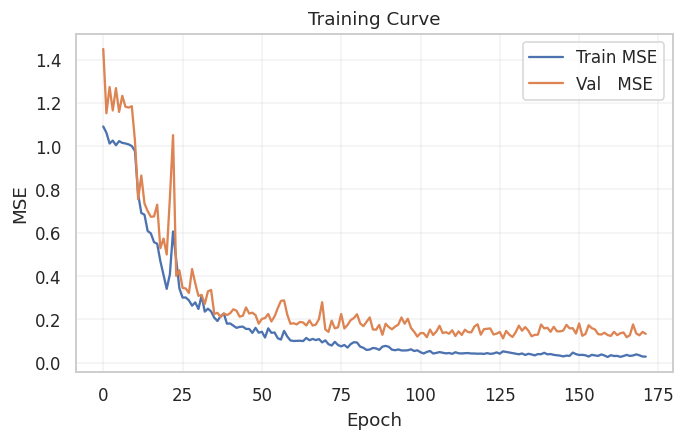

In [11]:
plt.figure(figsize=(7, 4))

plt.plot(history["train"], label="Train MSE")
plt.plot(history["val"  ], label="Val   MSE")

plt.xlabel("Epoch")
plt.ylabel("MSE"  )
plt.title ("Training Curve")

plt.grid  (alpha=0.25)
plt.legend()

plt.show()

In [12]:
train_pred, train_metrics = evaluate_metrics(model, X_train, y_train)
val_pred  , val_metrics   = evaluate_metrics(model, X_val  , y_val  )
test_pred , test_metrics  = evaluate_metrics(model, X_test , y_test )

metrics_df = pd.DataFrame(
    [
        train_metrics,
        val_metrics  ,
        test_metrics ,
    ],
    index=[
        "Train"     ,
        "Validation",
        "Test"      ,
    ],
).round(2)


display(metrics_df)

,mae,rmse,r2
Train,4.08,5.55,0.96
Validation,7.04,9.34,0.90
Test,8.27,11.89,0.84


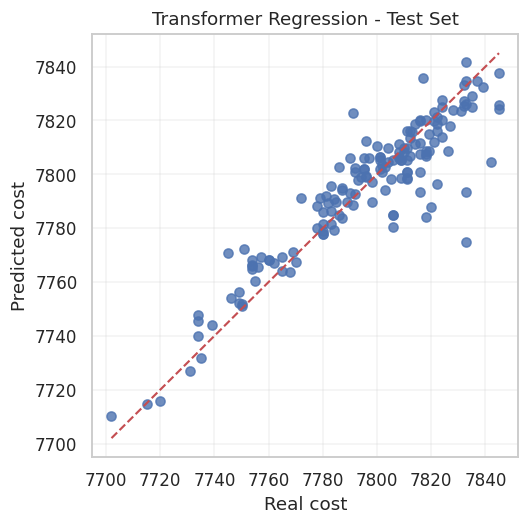

In [13]:
lo = min(float(y_test.min()), float(test_pred.min()))
hi = max(float(y_test.max()), float(test_pred.max()))


plt.figure(figsize=(5, 5))

plt.scatter(y_test, test_pred, alpha=0.8)
plt.plot   (
    [lo, hi],
    [lo, hi],
    "r--"   ,
    linewidth=1.4
)

plt.xlabel("Real cost"     )
plt.ylabel("Predicted cost")
plt.title ("Transformer Regression - Test Set")

plt.grid(alpha=0.25)

plt.show()

### CONTEXT ANALYSIS

Displaying the aggregated context matrix:

In [14]:
@torch.no_grad()
def aggregate_context_matrix(
    model,
    X_np       : np.ndarray,
    layer_index: int = -1  ,
    batch_size : int = 64  ,
) -> np.ndarray:
    model.eval()

    X_t    = torch.tensor(X_np, dtype=torch.long)
    loader = DataLoader  (
        TensorDataset(X_t), batch_size=batch_size, shuffle=False
    )

    context_sum  = None
    sample_count = 0

    for (xb,) in loader:
        xb = xb.to(DEVICE)

        _, attn_maps = model(xb, return_attn=True)

        attn     = attn_maps[layer_index]
        attn     = attn.mean(dim=1)
        attn_fac = attn[:, 1:, 1:]

        batch_context = attn_fac.sum(dim=0).cpu().numpy()

        if context_sum is None:
            context_sum  = batch_context
        else:
            context_sum += batch_context

        sample_count += attn_fac.shape[0]

    if context_sum is None or sample_count == 0:
        raise RuntimeError(
            "Could not compute attention context matrix."
        )

    return context_sum / sample_count


context_full = aggregate_context_matrix(
    model, X, layer_index=0, batch_size=64
)

print(f"Context matrix shape is {context_full.shape}.")

Context matrix shape is (300, 300).


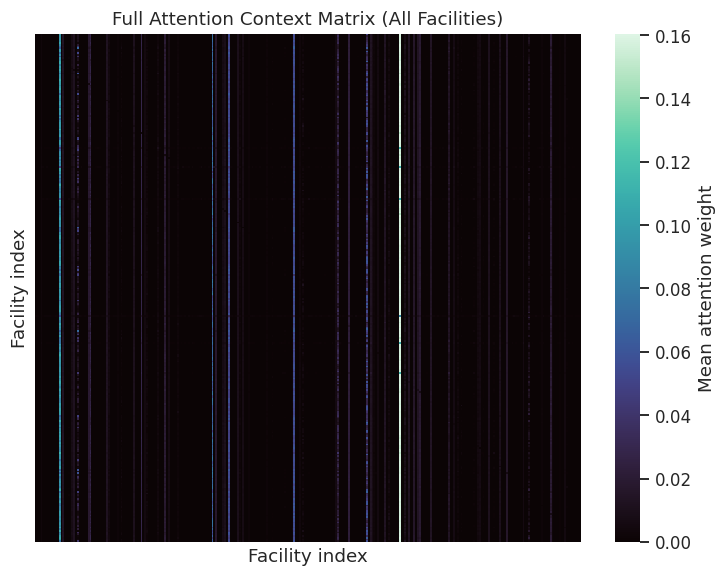

In [15]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    context_full,
    cmap       ="mako",
    xticklabels=False ,
    yticklabels=False ,
    cbar_kws={
        "label": "Mean attention weight"
    },
)

plt.title ("Full Attention Context Matrix (All Facilities)")
plt.xlabel("Facility index")
plt.ylabel("Facility index")

plt.show()

In [16]:
n_facilities = context_full.shape[0]

pairs  = np.argwhere(
    ~np.eye(
        n_facilities, dtype=bool
    )
)
scores = context_full[pairs[:,0], pairs[:,1]]

top_k   = min(20, len(scores))
top_pos = np.argsort(scores)[-top_k:][::-1]

print("Top facility pairs by mean context attention:")
for rank, pos in enumerate(top_pos, 1):
    i, j = pairs[pos]

    print(f"{rank:2d}. Facility {i:3d} -> {j:3d} : {scores[pos]*100:.2f}%")

Top facility pairs by mean context attention:
 1. Facility  91 -> 200 : 16.04%
 2. Facility 167 -> 200 : 16.03%
 3. Facility 174 -> 200 : 16.01%
 4. Facility 297 -> 200 : 16.00%
 5. Facility   6 -> 200 : 16.00%
 6. Facility  51 -> 200 : 15.98%
 7. Facility  90 -> 200 : 15.98%
 8. Facility 229 -> 200 : 15.98%
 9. Facility 207 -> 200 : 15.95%
10. Facility  53 -> 200 : 15.95%
11. Facility  84 -> 200 : 15.95%
12. Facility  79 -> 200 : 15.95%
13. Facility  88 -> 200 : 15.94%
14. Facility 201 -> 200 : 15.94%
15. Facility  81 -> 200 : 15.94%
16. Facility 149 -> 200 : 15.94%
17. Facility 154 -> 200 : 15.93%
18. Facility 150 -> 200 : 15.93%
19. Facility 168 -> 200 : 15.93%
20. Facility   7 -> 200 : 15.93%


Displaying only the features used in some long-term memory solution:

In [17]:
used_mask = X.sum   (axis=0   ) > 0
used_idx  = np.where(used_mask)[0]

context_used = context_full[
    np.ix_(used_idx, used_idx)
]


print(f"Used facilities: {len(used_idx)} / {X.shape[1]}.")

Used facilities: 59 / 300.


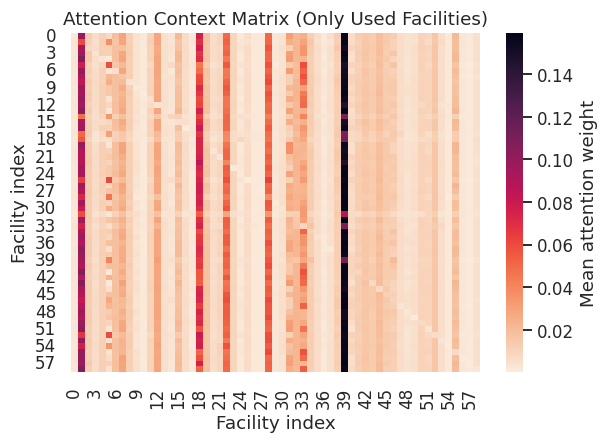

In [18]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    context_used,
    cmap    ="rocket_r",
    cbar_kws={
        "label": "Mean attention weight"
    },
)

plt.title ("Attention Context Matrix (Only Used Facilities)")
plt.xlabel("Facility index")
plt.ylabel("Facility index")

plt.show()

### FEATURE-LEVEL INTERPRETATION

Collect attention by layer head:

In [19]:
@torch.no_grad()
def collect_attention_by_layer_head(
    model,
    X_np      : np.ndarray,
    batch_size: int = 64  ,
) -> np.ndarray:
    model.eval()

    X_t    = torch.tensor(X_np, dtype=torch.long)
    loader = DataLoader  (
        TensorDataset(X_t), batch_size=batch_size, shuffle=False
    )

    layer_sums = None
    n_samples  = 0

    for (xb,) in loader:
        xb = xb.to(DEVICE)

        _, attn_maps = model(xb, return_attn=True)

        if layer_sums is None:
            layer_sums = [
                np.zeros(
                    attn.shape[1:], dtype=np.float64
                )
                for attn in attn_maps
            ]

        for li, attn in enumerate(attn_maps):
            layer_sums[li] += attn.sum(dim=0).cpu().numpy()

        n_samples += xb.size(0)

    if layer_sums is None or n_samples == 0:
        raise RuntimeError(
            "Could not collect attention statistics."
        )

    return np.stack(
        [
            s / n_samples
            for s in layer_sums
        ],
        axis=0
    )


attn_lh = collect_attention_by_layer_head(
    model, X, batch_size=64
)

n_layers, n_heads, n_tokens, _ = attn_lh.shape


print(f"Collected attention:")
print()

print(f"Layers ={n_layers}")
print(f"Heads  ={n_heads }")
print(f"Tokens ={n_tokens}")

Collected attention:

Layers =2
Heads  =5
Tokens =301


In [20]:
attn_fac = attn_lh[:, :, 1:, 1:]

_, _, n_fac, _ = attn_fac.shape
if n_fac <= 1:
    raise RuntimeError(
        "Need at least 2 facilities to compute attention-based feature importance."
    )

In [21]:
TOP_K_ATTN     = min(15, n_fac)
TOP_K_PER_HEAD = min(10, n_fac)


diag = np.diagonal(attn_fac, axis1=-2, axis2=-1)

outgoing = (attn_fac.sum(axis=-1) - diag) / (n_fac - 1)
incoming = (attn_fac.sum(axis=-2) - diag) / (n_fac - 1)

layer_head_feature_score = 0.5 * (outgoing + incoming)

layer_feature_score = layer_head_feature_score.mean(axis=1)
head_feature_score  = layer_head_feature_score.mean(axis=0)
attention_score     = layer_head_feature_score.mean(axis=(0, 1))

top_attention_idx = np.argsort  (attention_score)[-TOP_K_ATTN:][::-1]
attention_rank_df = pd.DataFrame(
    {
        "facility"        : top_attention_idx                 ,
        "attention_score" : attention_score[top_attention_idx],
    }
)

head_rows = []
for layer_idx    in range(n_layers):
    for head_idx in range(n_heads ):
        scores  = layer_head_feature_score[layer_idx, head_idx]

        top_idx = np.argsort(scores)[-TOP_K_PER_HEAD:][::-1]
        for rank, idx in enumerate(top_idx, start=1):
            head_rows.append(
                {
                    "layer"           : int  (layer_idx  ),
                    "head"            : int  (head_idx   ),
                    "rank"            : int  (rank       ),
                    "facility"        : int  (idx        ),
                    "attention_score" : float(scores[idx]),
                }
            )

head_rank_df = pd.DataFrame(head_rows)

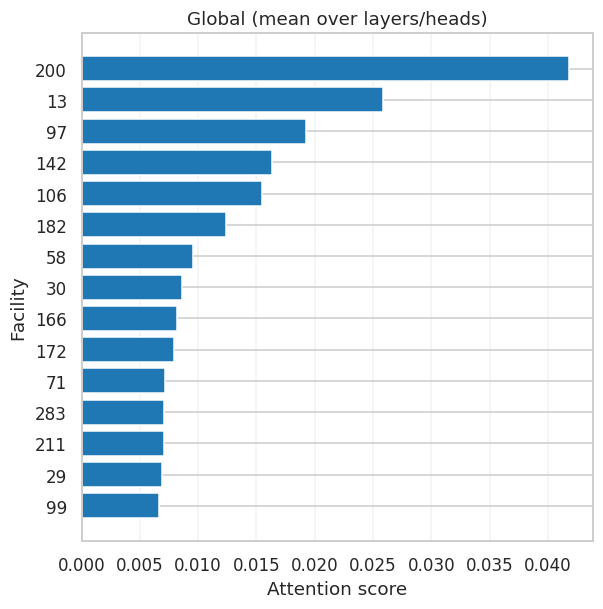

In [22]:
global_df = attention_rank_df.iloc[::-1]


fig, ax = plt.subplots(figsize=(6, 6))

ax.barh(
    global_df["facility"       ].astype(str),
    global_df["attention_score"]            ,
    color="tab:blue"
)

ax.set_title ("Global (mean over layers/heads)")
ax.set_xlabel("Attention score")
ax.set_ylabel("Facility       ")

ax.grid(axis="x", alpha=0.25)

plt.show()

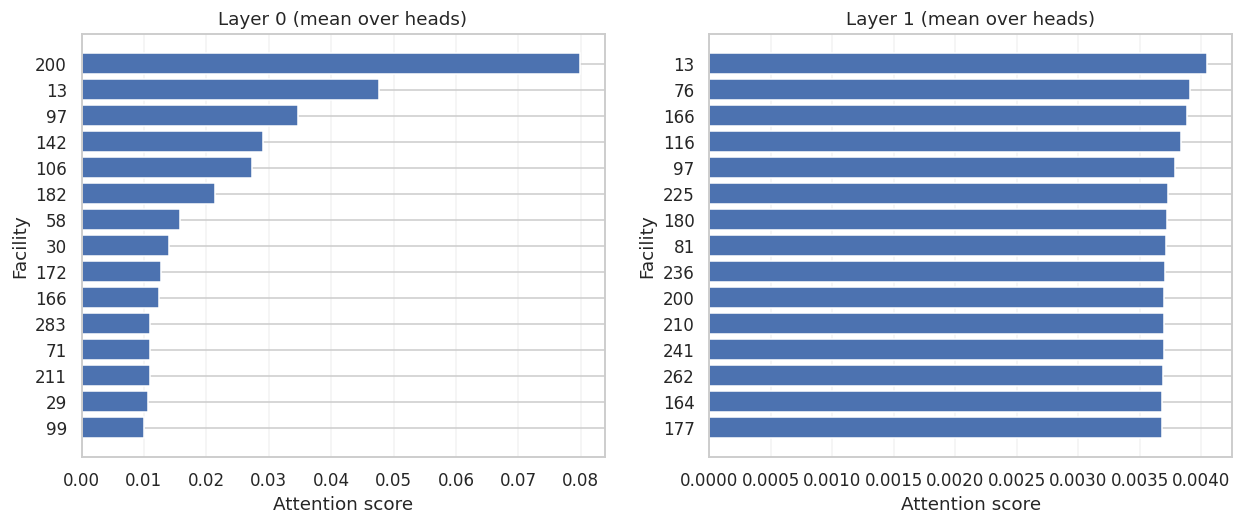

In [23]:
fig, axes = plt.subplots(
    1, n_layers, figsize=(4.5 * (n_layers + 1), 5)
)

for layer_idx in range(n_layers):
    scores  = layer_feature_score[layer_idx   ]
    top_idx = np.argsort(scores )[-TOP_K_ATTN:][::-1]

    ax = axes[layer_idx]

    ax.barh(
        [
            str(i) for i in top_idx[::-1]
        ],
        scores[top_idx][::-1]
    )

    ax.set_title (f"Layer {layer_idx} (mean over heads)")
    ax.set_xlabel("Attention score")
    ax.set_ylabel("Facility"       )

    ax.grid(axis="x", alpha=0.25)

plt.show()

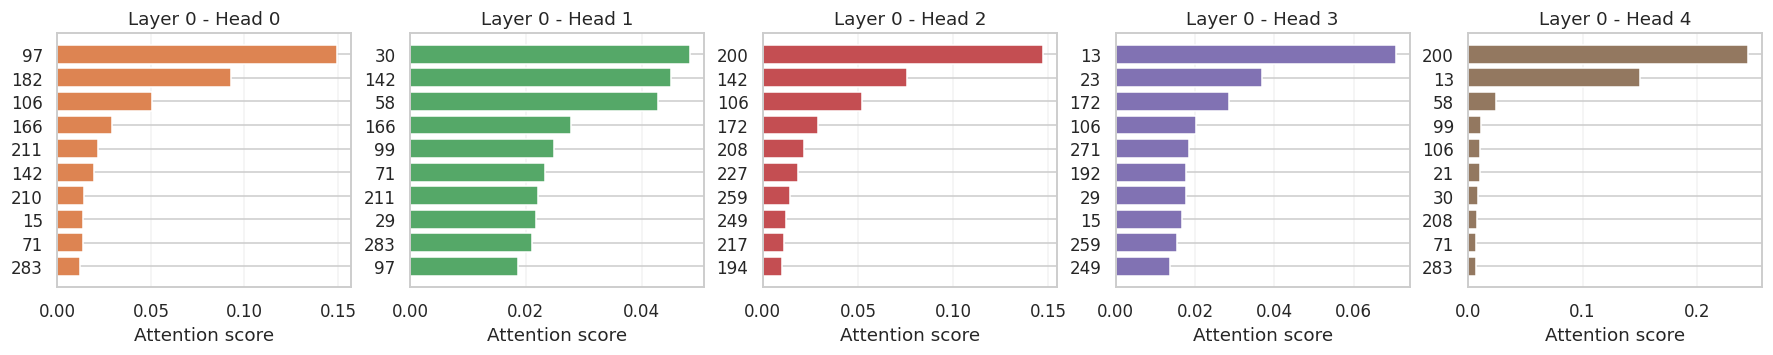

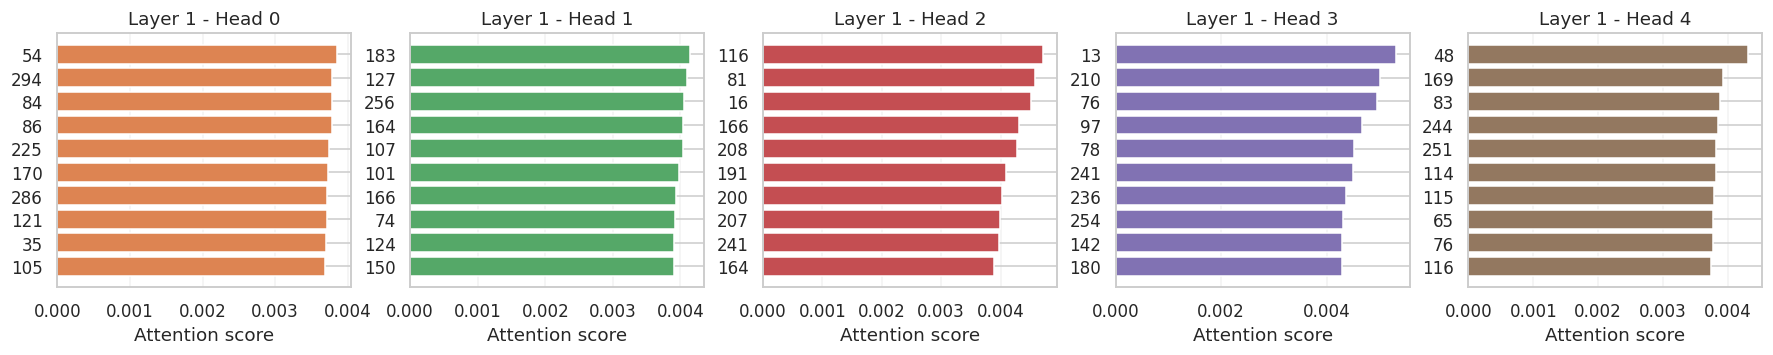

In [24]:
for layer_idx in range(n_layers):
    fig, axes = plt.subplots(
        1      ,
        n_heads,
        figsize=(
            4 * n_heads, 3
        ),
        sharex=False,
        sharey=False,
    )

    for head_idx in range(n_heads):
        df_h = head_rank_df[
            (head_rank_df["layer"] == layer_idx) & 
            (head_rank_df["head" ] == head_idx )
        ]
        df_h = df_h.sort_values("rank", ascending=False)

        ax = axes[head_idx]

        ax.barh(
            df_h["facility"       ].astype(str),
            df_h["attention_score"]            ,
            color=f"C{(head_idx + 1) % 10}"    ,
        )

        ax.set_title (f"Layer {layer_idx} - Head {head_idx}")
        ax.set_xlabel("Attention score")

        ax.grid(axis="x", alpha=0.25)

    plt.show()

### ATTENTION-COOCCURRENCE INTERACTION ANALYSIS

This analysis compares pairwise attention learned by the Transformer with the empirical co-occurrence of facilities across solutions. Attention matrices aggregated across layers and heads capture how strongly the model relates two facilities within its internal contextual representation.

To ground these relationships in the solution space, we compute co-occurrence statistics from the binary solution matrix and contrast them with the co-occurrence observed in the best solutions. The difference between these two quantities (lift) reveals whether a pair of facilities appears more or less frequently in high-quality solutions compared to the overall solution population.

By combining attention strength with co-occurrence lift, facility pairs are heuristically categorized as synergy, redundancy, or conflict. This provides an interpretable view of how the Transformer captures structural interactions between facilities and whether those interactions align with patterns observed in the best solutions.

In [25]:
attn_pair_directed = attn_fac.mean(axis=(0, 1))

attn_pair_sym      = 0.5 * (
    attn_pair_directed + attn_pair_directed.T
)

np.fill_diagonal(attn_pair_sym, 0.0)


X_int = X.astype(np.int16)
coocc = (X_int.T @ X_int ).astype(float)

coocc_norm = coocc / float(len(X))

np.fill_diagonal(coocc_norm, 0.0)


n_best_pairs   = max(5, int(np.ceil(0.10 * len(X))))
best_ids_pairs = np.argsort(y)[:n_best_pairs]

coocc_best      = (
    X_int[best_ids_pairs].T @ X_int[best_ids_pairs]
).astype(float)

coocc_best_norm = coocc_best / float(len(best_ids_pairs))

np.fill_diagonal(coocc_best_norm, 0.0)


lift_best_vs_all = coocc_best_norm - coocc_norm


u, v = np.triu_indices(X.shape[1], k=1)


pair_df = pd.DataFrame(
    {
        "facility_i"       : u,
        "facility_j"       : v,
        "attention"        : attn_pair_sym   [u, v],
        "coocc_all"        : coocc_norm      [u, v],
        "coocc_best"       : coocc_best_norm [u, v],
        "lift_best_vs_all" : lift_best_vs_all[u, v],
    }
)

Heuristic interaction labels:

In [26]:
attn_q      = float(pair_df["attention"       ].quantile(0.90))
coocc_q_low = float(pair_df["coocc_all"       ].quantile(0.30))
lift_q_hi   = float(pair_df["lift_best_vs_all"].quantile(0.90))
lift_q_lo   = float(pair_df["lift_best_vs_all"].quantile(0.10))

pair_df["interaction"] = "neutral"

mask_conflict   = (pair_df["attention"] >= attn_q) & (pair_df["lift_best_vs_all"] <= lift_q_lo  )
mask_synergy    = (pair_df["attention"] >= attn_q) & (pair_df["lift_best_vs_all"] >= lift_q_hi  )
mask_redundancy = (pair_df["attention"] >= attn_q) & (pair_df["coocc_all"       ] <= coocc_q_low)

pair_df.loc[mask_conflict                   , "interaction"] = "conflict"
pair_df.loc[mask_redundancy & ~mask_conflict, "interaction"] = "redundancy"
pair_df.loc[mask_synergy    & ~mask_conflict, "interaction"] = "synergy"


print(pair_df["interaction"].value_counts())

interaction
neutral     40365
conflict     4426
synergy        59
Name: count, dtype: int64


In [27]:
TOP_SHOW = 10


display(pair_df[pair_df["interaction"] == "synergy" ].sort_values("lift_best_vs_all", ascending=False).head(TOP_SHOW))
display(pair_df[pair_df["interaction"] == "conflict"].sort_values("lift_best_vs_all", ascending=True ).head(TOP_SHOW))

,facility_i,facility_j,attention,coocc_all,coocc_best,lift_best_vs_all,interaction
8582,30,78,0.006037,0.052699,0.166667,0.113967,synergy
8670,30,166,0.009001,0.062982,0.166667,0.103685,synergy
6678,23,78,0.010358,0.204370,0.307692,0.103322,synergy
6630,23,30,0.012096,0.077121,0.179487,0.102366,synergy
8571,30,67,0.007316,0.061697,0.153846,0.092149,synergy
8601,30,97,0.020154,0.066838,0.153846,0.087008,synergy
6766,23,166,0.006112,0.215938,0.294872,0.078933,synergy
6667,23,67,0.012124,0.217224,0.294872,0.077648,synergy
6803,23,203,0.008743,0.025707,0.102564,0.076857,synergy
15796,58,166,0.010004,0.039846,0.115385,0.075539,synergy


,facility_i,facility_j,attention,coocc_all,coocc_best,lift_best_vs_all,interaction
36749,172,200,0.045462,0.052699,0.025641,-0.027058,conflict
6792,23,192,0.007882,0.026992,0.000000,-0.026992,conflict
26188,106,166,0.012864,0.064267,0.038462,-0.025806,conflict
3901,13,106,0.036942,0.025707,0.000000,-0.025707,conflict
3961,13,166,0.023278,0.151671,0.128205,-0.023466,conflict
20346,78,106,0.012176,0.048843,0.025641,-0.023202,conflict
24355,97,106,0.032164,0.048843,0.025641,-0.023202,conflict
35944,166,172,0.011019,0.035990,0.012821,-0.023169,conflict
36055,166,283,0.010103,0.023136,0.000000,-0.023136,conflict
36731,172,182,0.013493,0.023136,0.000000,-0.023136,conflict


Correlation between transformer context and co-occurrence:

In [28]:
def _rank_corr(a, b):
    ra = pd.Series(a).rank(method="average").to_numpy()
    rb = pd.Series(b).rank(method="average").to_numpy()

    return float(np.corrcoef(ra, rb)[0, 1])


pearson_corr  = float(
    np.corrcoef(
        pair_df["attention"],
        pair_df["coocc_all"],
    )[0, 1]
)
spearman_corr = _rank_corr(
    pair_df["attention"],
    pair_df["coocc_all"],
)


print(f"Correlation attention vs co-occurrence (Pearson ): {pearson_corr :.2f}%")
print(f"Correlation attention vs co-occurrence (Spearman): {spearman_corr:.2f}%")

Correlation attention vs co-occurrence (Pearson ): 0.17%
Correlation attention vs co-occurrence (Spearman): 0.16%


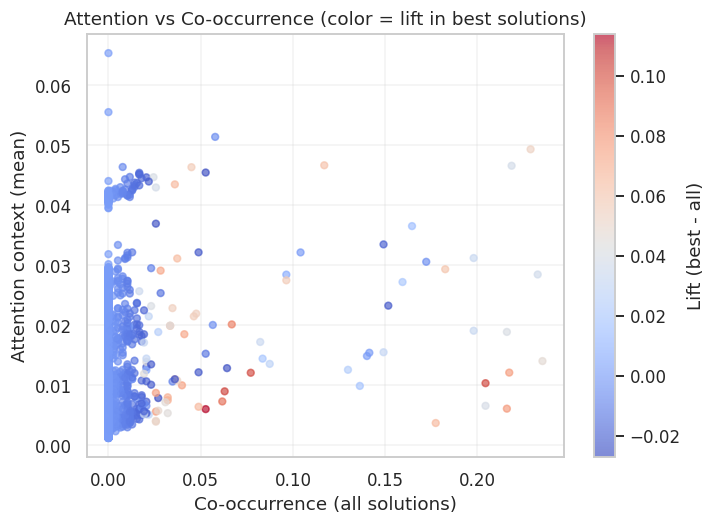

In [29]:
plt.figure(figsize=(7, 5))

sc = plt.scatter(
    pair_df  ["coocc_all"       ],
    pair_df  ["attention"       ],
    c=pair_df["lift_best_vs_all"],
    alpha=0.65,
    s    =20  ,
    cmap ="coolwarm",
)

plt.title   ("Attention vs Co-occurrence (color = lift in best solutions)")
plt.xlabel  ("Co-occurrence (all solutions)")
plt.ylabel  ("Attention context (mean)"     )
plt.colorbar(sc, label="Lift (best - all)"  )

plt.grid(alpha=0.25)

plt.show()